In [1]:
from pathlib import Path
import numpy as np 
import pandas as pd 
import geopandas as gpd
import xarray as xr
import matplotlib.pyplot as plt
import pickle

### Load the file output by the process_icesat2.ipynb

In [2]:
atl06sr_gdf = pickle.load(open('../../data/icesat2/sierras_gdf_2018_2021_sa_processed.pkl', 'rb'))

In [3]:
sierras = gpd.read_file('../../data/misc/sierras_polygon_gmba.geojson')

In [4]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(2019, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds['SD_Post'] = sd_ds['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds['SWE_Post'] = swe_sca_ds['SWE_Post'].T
swe_sca_ds['SCA_Post'] = swe_sca_ds['SCA_Post'].T
swe_sca_ds = swe_sca_ds.transpose('time', 'y', 'x')
swe_sca_ds.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 23GB
Dimensions:      (time: 1096, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 9kB 2018-10-01 2018-10-02 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 8GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

In [5]:
# use open_mfdataset to open all years of swe/sca data at once, then open all sd data at once, and merge the two datasets saving the output file

base_dir = '../../swe_reanalysis_pca/data/download'

swe_sca_files = []
sd_files = []

for year in range(1985, 2022):
    year_folder = Path(base_dir) / str(year)
    swe_sca_files.append(f"{base_dir}/{year}/SWE_SCA_POST_{year}.nc")
    sd_files.append(f"{base_dir}/{year}/SD_POST_{year}.nc")

def preprocess_swe(ds):
    ds = ds.rename({'Latitude': 'y', 'Longitude': 'x'})
    ds = ds.rio.set_spatial_dims('y', 'x', inplace=True)
    return ds

swe_sca_ds_allyrs = xr.open_mfdataset(
    swe_sca_files,
    combine='by_coords',
    preprocess=preprocess_swe
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)


sd_ds_allyrs = xr.open_mfdataset(
    sd_files,
    combine='by_coords'
    # chunks={'Latitude': 1575, 'Longitude': 1125, 'time': 366},
    # parallel=True
)

swe_sca_ds_allyrs['SD_Post'] = sd_ds_allyrs['SD_Post']


# swe_sca_ds = swe_sca_ds.rename({'Latitude': 'y', 'Longitude': 'x'})
# swe_sca_ds = swe_sca_ds.rio.set_spatial_dims('y', 'x', inplace=True)
swe_sca_ds_allyrs['SWE_Post'] = swe_sca_ds_allyrs['SWE_Post'].T
swe_sca_ds_allyrs['SCA_Post'] = swe_sca_ds_allyrs['SCA_Post'].T
swe_sca_ds_allyrs = swe_sca_ds_allyrs.transpose('time', 'y', 'x')
swe_sca_ds_allyrs.rio.write_crs('EPSG:4326', inplace=True)
#swe_sca_ds['SD_Post'] = swe_sca_ds['SD_Post'].T

<xarray.Dataset> Size: 287GB
Dimensions:      (time: 13514, y: 1575, x: 1125)
Coordinates:
  * y            (y) float32 6kB 34.0 34.01 34.01 34.02 ... 40.99 40.99 41.0
  * x            (x) float32 4kB -122.0 -122.0 -122.0 ... -117.0 -117.0 -117.0
  * time         (time) datetime64[ns] 108kB 1984-10-01 ... 2021-09-30
    spatial_ref  int64 8B 0
Data variables:
    SWE_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SCA_Post     (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>
    SD_Post      (time, y, x) float32 96GB dask.array<chunksize=(61, 263, 188), meta=np.ndarray>

### Get timeseries of median/average reanalysis snow depth:

In [6]:
swe_sca_ds = swe_sca_ds.rename({'y': 'lat', 'x': 'lon'})

In [7]:
swe_sca_ds_allyrs = swe_sca_ds_allyrs.rename({'y': 'lat', 'x': 'lon'})

In [8]:
# 1. Select April 1 of each year
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs.sel(time=( (swe_sca_ds_allyrs['time'].dt.month == 4) & (swe_sca_ds_allyrs['time'].dt.day == 1) ))

In [9]:
# 2. Compute mean April 1 snow depth across years
swe_sca_ds_allyrs_april1 = swe_sca_ds_allyrs_april1.mean(dim='time', skipna=True)

In [10]:
# 3. Threshold mask
mask = swe_sca_ds_allyrs_april1.SCA_Post > 0.5

In [11]:
mask_da = mask.astype(np.int32)

In [12]:
latitudes = xr.DataArray(atl06sr_gdf.to_crs('epsg:4326').geometry.y.values, dims="points")
longitudes = xr.DataArray(atl06sr_gdf.to_crs('epsg:4326').geometry.x.values, dims="points")

In [13]:
#atl06sr_gdf['mask'] = np.nan

sampled_mask = mask_da.sel(lat=latitudes, lon=longitudes, method='nearest').values

In [14]:
atl06sr_gdf['mask'] = sampled_mask

In [15]:
atl06sr_gdf.to_pickle('../../data/icesat2/sierras_gdf_2018_2021_sa_processed_masked.pkl')

In [60]:
elev_min = np.arange(1000, 4400, 200)
elev_max = np.arange(1200, 4600, 200)
elev_max

array([1200, 1400, 1600, 1800, 2000, 2200, 2400, 2600, 2800, 3000, 3200,
       3400, 3600, 3800, 4000, 4200, 4400])

In [61]:
slope_min = np.arange(0, 70, 10)
slope_max = np.arange(10, 80, 10)
slope_max

array([10, 20, 30, 40, 50, 60, 70])

/opt/homebrew/Caskroom/miniforge/base/envs/analog_mapping/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:1215: RuntimeWarning: Mean of empty slice
  return np.nanmean(a, axis, out=out, keepdims=keepdims)


Text(0.5, 1.0, 'By Elevation, with all slopes and fsca > 0.9')

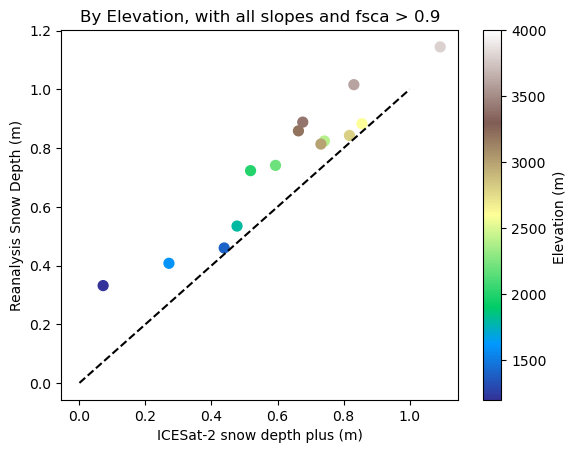

In [62]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='terrain', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m) ')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation, with all slopes and fsca > 0.9')

Text(0.5, 1.0, 'By Elevation, with all slopes and all fsca values')

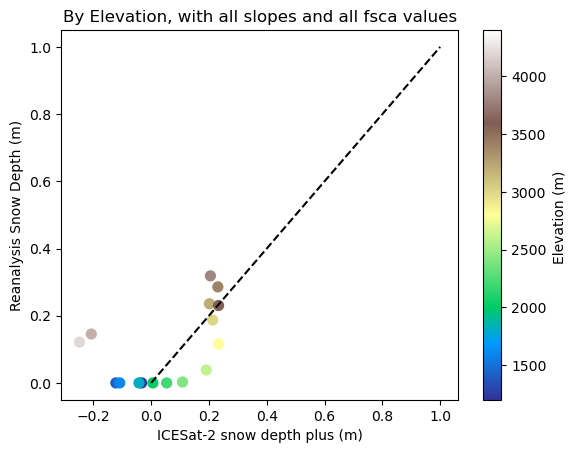

In [21]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='terrain', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m) ')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation, with all slopes and all fsca values')

(-0.5, 1.3)

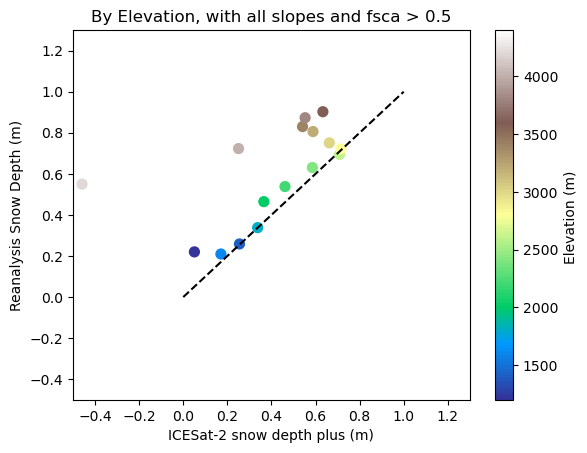

In [40]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='terrain', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m) ')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation, with all slopes and fsca > 0.5')
plt.xlim(-0.5, 1.3)
plt.ylim(-0.5, 1.3)

(0.0, 1.3)

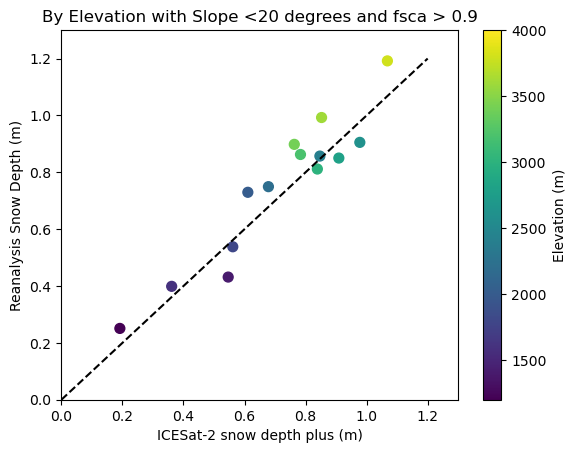

In [36]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1.2, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with Slope <20 degrees and fsca > 0.9')
plt.xlim(0, 1.3)
plt.ylim(0, 1.3)

(0.0, 1.3)

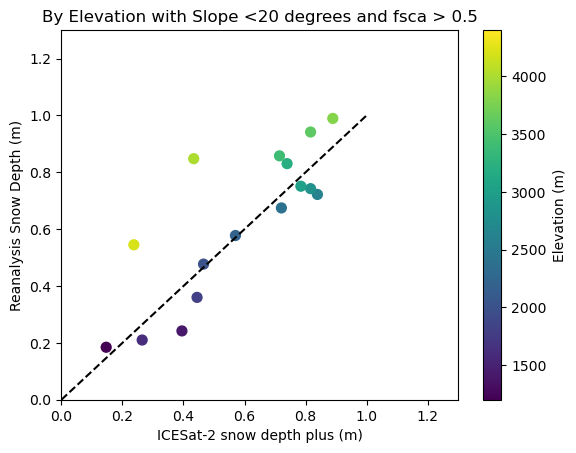

In [37]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with Slope <20 degrees and fsca > 0.5')
plt.xlim(0, 1.3)
plt.ylim(0, 1.3)

(0.0, 1.3)

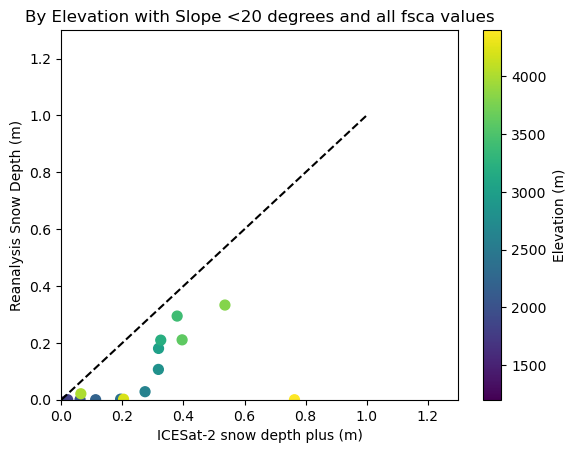

In [38]:
x_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=elev_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Elevation (m)')

plt.plot(x, y, color='k', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Elevation with Slope <20 degrees and all fsca values')
plt.xlim(0, 1.3)
plt.ylim(0, 1.3)

### Plot slope:

Text(0.5, 1.0, 'By Slope, with all Elevations and fsca >0.9')

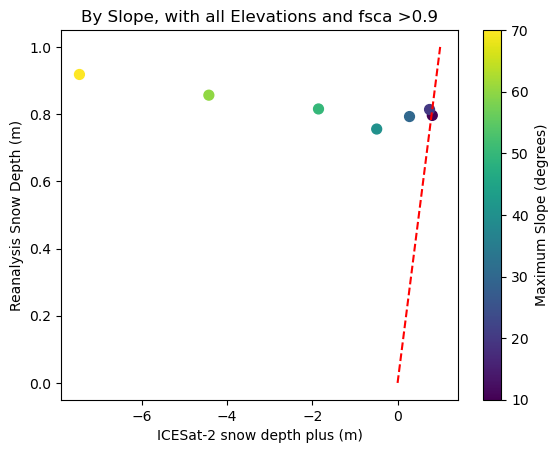

In [30]:
x_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=slope_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Maximum Slope (degrees)')

plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Slope, with all Elevations and fsca >0.9')

Text(0.5, 1.0, 'By Slope, with all Elevations and fsca >0.5')

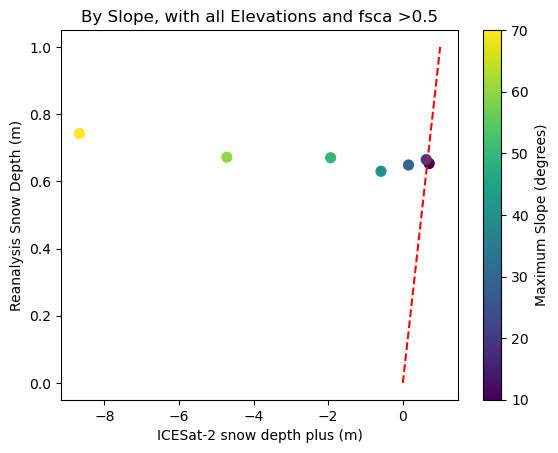

In [31]:
x_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.5) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=slope_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Maximum Slope (degrees)')

plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Slope, with all Elevations and fsca >0.5')

Text(0.5, 1.0, 'By Slope, with all Elevations and all fsca values')

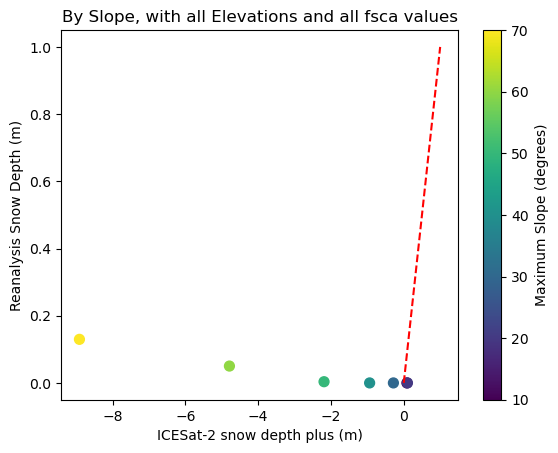

In [32]:
x_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    x_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values))

y_medians = []
for x_min, x_max in zip(slope_min, slope_max):
    y_medians.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values))

x = np.linspace(0, 1, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots()
scatter = ax.scatter(x_medians, y_medians, c=slope_max, cmap='viridis', s=50, zorder=2) # zorder to ensure markers are on top
cbar = fig.colorbar(scatter, ax=ax, label='Maximum Slope (degrees)')

plt.plot(x, y, color='red', linestyle='--', label='1:1 Line')

plt.xlabel('ICESat-2 snow depth plus (m)')
plt.ylabel('Reanalysis Snow Depth (m)')
plt.title('By Slope, with all Elevations and all fsca values')

In [65]:
x_medians1 = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians1.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians1 = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians1.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x_medians2 = []
for x_min, x_max in zip(elev_min, elev_max):
    x_medians2.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'icesat2_3dep_dif'].values))

y_medians2 = []
for x_min, x_max in zip(elev_min, elev_max):
    y_medians2.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']<20) & (atl06sr_gdf['h_mean']>x_min) & (atl06sr_gdf['h_mean']<x_max),'reanalysis_sd'].values))

x_medians3 = []
for x_min, x_max in zip(slope_min, slope_max):
    x_medians3.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'icesat2_3dep_dif'].values))

y_medians3 = []
for x_min, x_max in zip(slope_min, slope_max):
    y_medians3.append(np.nanmedian(atl06sr_gdf.loc[(atl06sr_gdf['reanalysis_sca']>0.9) & (atl06sr_gdf['slope']>x_min) & (atl06sr_gdf['slope']<x_max),'reanalysis_sd'].values))



In [66]:
x_medians1

[np.float64(0.07175673921119596),
 np.float64(0.43845780887397723),
 np.float64(0.2711356278543917),
 np.float64(0.477344491709232),
 np.float64(0.5183262261871278),
 np.float64(0.5939183719779066),
 np.float64(0.7419755431992598),
 np.float64(0.855752011558252),
 np.float64(0.8178819089032459),
 np.float64(0.7313680579486572),
 np.float64(0.6633292481205899),
 np.float64(0.6764352582436004),
 np.float64(0.8312183770726733),
 np.float64(1.0926408588022696),
 np.float64(0.9839257092558),
 np.float64(nan),
 np.float64(nan)]

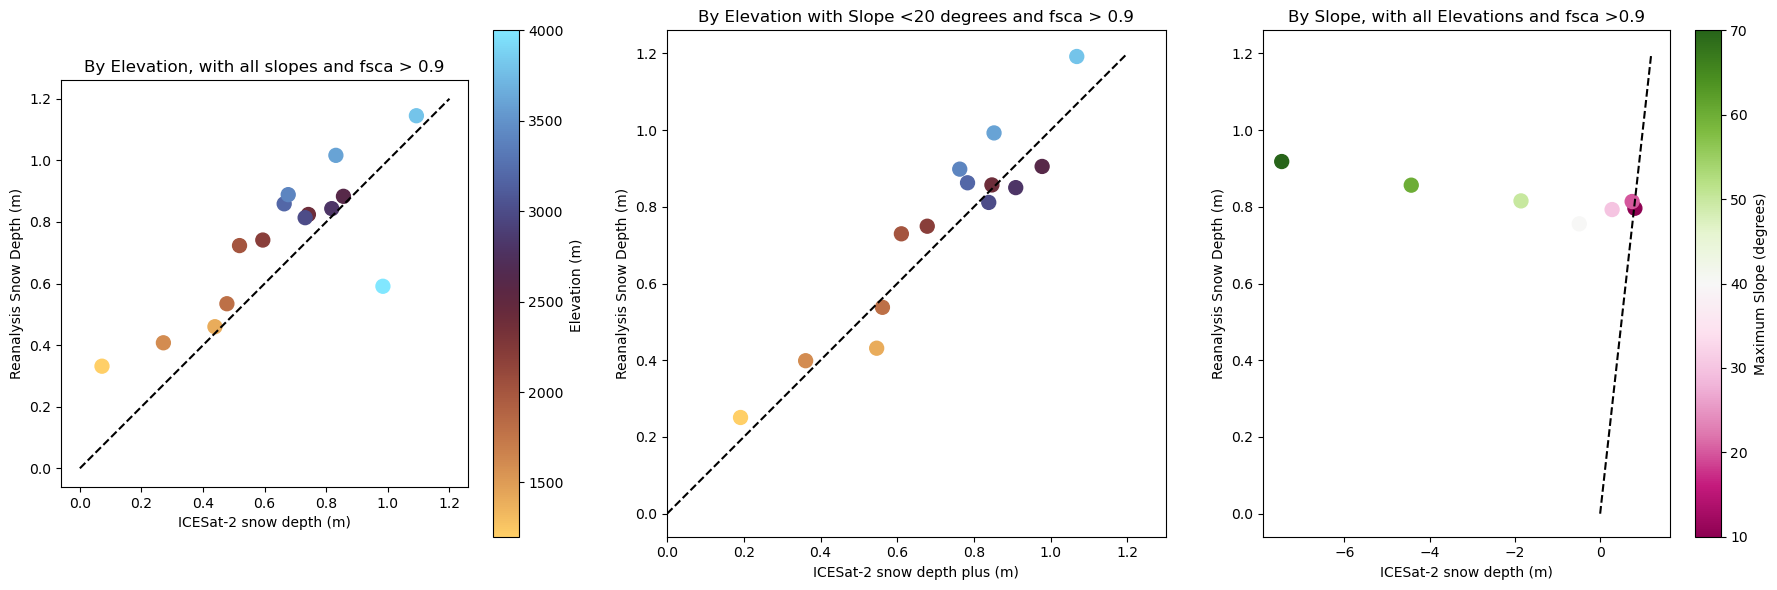

In [89]:
x = np.linspace(0, 1.2, 100) # Creates 100 points between x_min and x_max
y = x

fig, ax = plt.subplots(1,3, figsize=(18,6))

scatter1 = ax[0].scatter(x_medians1, y_medians1, c=elev_max, cmap='managua', s=100, zorder=2) # zorder to ensure markers are on top
cbar1 = fig.colorbar(scatter1, ax=ax[0], label='Elevation (m) ')
ax[0].plot(x, y, color='k', linestyle='--', label='1:1 Line')
ax[0].set_xlabel('ICESat-2 snow depth (m)')
ax[0].set_ylabel('Reanalysis Snow Depth (m)')
ax[0].set_title('By Elevation, with all slopes and fsca > 0.9')
ax[0].set_aspect('equal', adjustable='box')


scatter2 = ax[1].scatter(x_medians2, y_medians2, c=elev_max, cmap='managua', s=100, zorder=2) # zorder to ensure markers are on top
#cbar2 = fig.colorbar(scatter2, ax=ax, label='Elevation (m)')
ax[1].plot(x, y, color='k', linestyle='--', label='1:1 Line')
ax[1].set_xlabel('ICESat-2 snow depth plus (m)')
ax[1].set_ylabel('Reanalysis Snow Depth (m)')
ax[1].set_title('By Elevation with Slope <20 degrees and fsca > 0.9')
ax[1].set_xlim(0, 1.3)
ax[1].set_aspect('equal', adjustable='box')

scatter3 = ax[2].scatter(x_medians3, y_medians3, c=slope_max, cmap='PiYG', s=100, zorder=2) # zorder to ensure markers are on top
cbar3 = fig.colorbar(scatter3, ax=ax[2], label='Maximum Slope (degrees)')
ax[2].plot(x, y, color='k', linestyle='--', label='1:1 Line')
ax[2].set_xlabel('ICESat-2 snow depth (m)')
ax[2].set_ylabel('Reanalysis Snow Depth (m)')
ax[2].set_title('By Slope, with all Elevations and fsca >0.9')
#ax[2].set_aspect('equal', adjustable='box')
#plt.subplots_adjust(right=0.85) 
fig.tight_layout()
